# 03 - Purification: No-Purification vs. Purification-Activated

## Objetivo
Comparar dois intents sobre a mesma topologia `a - r - b`, diferindo apenas
em `min_fidelity`: um caso em que o swap isolado já satisfaz o requisito
(purificação não é acionada) e um caso em que o requisito só é alcançável
purificando (estado `PURIFIED`), demonstrando que `IntentRequestApp` conta
corretamente pares entregues no estado `PURIFIED` - algo que o
`RequestApp` padrão do SeQUeNCe **não** faz.

## Conceitos
- `PurifyUntilTarget` (a estratégia padrão do `IntentPlanner`) só tenta
  purificar quando a fidelidade de swap isolado fica abaixo de
  `min_fidelity` **e** `intent.policy.allow_purification` é `True`
  (`src/ibqn/planning/purification.py`).
- `RequestApp.get_memory` (SeQUeNCe core,
  `sequence/app/request_app.py:133`) começa com
  `if info.state != "ENTANGLED": return` - um par entregue via purificação
  bem-sucedida (`MemoryInfo.to_purified()`) fica no estado `"PURIFIED"`, não
  `"ENTANGLED"`, e por isso **nunca seria contado, resetado ou reportado**
  pelo app padrão. `IntentRequestApp._count_purified_delivery` espelha a
  mesma lógica de casamento/contagem para esse estado
  (`src/ibqn/execution/sequence_executor.py`, ver docstring da classe).
- Este notebook não força nenhum estado manualmente: a purificação (ou a
  ausência dela) é uma decisão real do `ResourceManager` do SeQUeNCe em
  tempo de execução, não algo escrito pelo planejador.
- `sequence.utils.metrics` é um singleton de processo: como este notebook
  roda dois casos independentes no mesmo kernel, cada rodada chama
  `metrics.configure()` primeiro (mesmo padrão de
  `ibqn.experiments.runner.run_scenario`) para partir de um `storage`
  vazio - sem isso, contadores diagnósticos por nó (`ep_success` etc.,
  não tagueados por `intent_id`) vazariam de um caso para o outro, já que
  os dois casos reutilizam os mesmos nomes de nó (`a`, `r`, `b`).


## Configuração


In [1]:
from sequence.utils import metrics
from ibqn.demos.topologies import three_node_spec
from ibqn.network.sequence_adapter import SequenceAdapter
from ibqn.network.capabilities import NetworkCapabilities
from ibqn.execution.sequence_executor import SequenceExecutor
from ibqn.intent.repository import IntentRepository
from ibqn.intent.models import (
    EntanglementIntent, IntentEndpoints, IntentRequirements, IntentPolicy, IntentValidation, SuccessCondition,
)
from ibqn.planning.planner import IntentPlanner

SEED = 0
REQUESTED_PAIRS = 10
RAW_FIDELITY = 0.85
SWAPPING_DEGRADATION = 0.95
# swap_only_fidelity = RAW_FIDELITY**2 * SWAPPING_DEGRADATION = 0.6864 (see notebook 02)

spec = three_node_spec(
    end_memories=REQUESTED_PAIRS, repeater_memories=REQUESTED_PAIRS * 2,
    raw_fidelity=RAW_FIDELITY, swapping_degradation=SWAPPING_DEGRADATION,
    stop_time_s=0.3,
)


def make_intent(intent_id: str, min_fidelity: float) -> EntanglementIntent:
    return EntanglementIntent(
        id=intent_id,
        endpoints=IntentEndpoints(source="a", destination="b"),
        requirements=IntentRequirements(
            min_fidelity=min_fidelity, min_throughput=1, max_latency=1.0,
            requested_pairs=REQUESTED_PAIRS, start_time=0.02, duration=0.2,
        ),
        policy=IntentPolicy(allow_purification=True),
        validation=IntentValidation(
            metrics=["delivered_pairs", "average_fidelity"],
            success_conditions=[
                SuccessCondition(metric="delivered_pairs", operator=">=", expected=1),
                SuccessCondition(metric="average_fidelity", operator=">=", expected=min_fidelity),
            ],
        ),
    )


intent_a = make_intent("intent-no-purification", min_fidelity=0.65)  # below swap_only_fidelity (0.6864)
intent_b = make_intent("intent-with-purification", min_fidelity=0.70)  # above swap_only, below purified estimate

capabilities = NetworkCapabilities(spec)
planner = IntentPlanner(capabilities)
plan_a = planner.plan(intent_a)
plan_b = planner.plan(intent_b)

print(f"Case A (min_fidelity={intent_a.requirements.min_fidelity}): requires_purification={plan_a.requires_purification}, "
      f"estimated_fidelity={plan_a.estimated_metrics.fidelity:.4f}")
print(f"Case B (min_fidelity={intent_b.requirements.min_fidelity}): requires_purification={plan_b.requires_purification}, "
      f"estimated_fidelity={plan_b.estimated_metrics.fidelity:.4f}")


2026-07-11 14:32:26,627 INFO     ibqn.ibqn.planning.planner intent_id=intent-no-purification - planned route a->r->b, estimated_fidelity=0.6864, purification=False


2026-07-11 14:32:26,634 INFO     ibqn.ibqn.planning.planner intent_id=intent-with-purification - planned route a->r->b, estimated_fidelity=0.7203, purification=True


Case A (min_fidelity=0.65): requires_purification=False, estimated_fidelity=0.6864
Case B (min_fidelity=0.7): requires_purification=True, estimated_fidelity=0.7203


## Execução

Cada caso roda em sua própria `Timeline`/`SequenceAdapter`, isolado do
outro. A evidência de cada caso é coletada **imediatamente após sua
própria rodada** (antes de rodar o caso seguinte): `metrics.configure()`
começa um `storage` novo a cada chamada, então esperar para coletar as
duas evidências só ao final apagaria os registros do primeiro caso assim
que o segundo chamasse `configure()`.


In [2]:
from ibqn.assurance.telemetry import collect_intent_evidence


def run_case(intent, plan, seed):
    metrics.configure()  # fresh storage: isolates this case's diagnostics from the other case
    adapter = SequenceAdapter(spec, seed=seed)
    repository = IntentRepository()
    executor = SequenceExecutor(adapter, repository)
    executor.deploy(intent, plan)
    executor.run()
    status = repository.get(intent.id).lifecycle.status
    evidence = collect_intent_evidence(intent)  # collected now: the next case's configure() would erase it
    return status, evidence

status_a, evidence_a = run_case(intent_a, plan_a, SEED)
status_b, evidence_b = run_case(intent_b, plan_b, SEED)
print(f"Case A final lifecycle status: {status_a}")
print(f"Case B final lifecycle status: {status_b}")


2026-07-11 14:32:26,667 INFO     ibqn.ibqn.network.sequence_adapter intent_id=- - topology built: 3 routers, 2 quantum links, seed=0


2026-07-11 14:32:26,668 INFO     ibqn.ibqn.intent.repository intent_id=intent-no-purification - intent registered


2026-07-11 14:32:26,670 INFO     ibqn.ibqn.intent.repository intent_id=intent-no-purification - intent transitioned to VALIDATED (schema validated)


2026-07-11 14:32:26,671 INFO     ibqn.ibqn.intent.repository intent_id=intent-no-purification - intent transitioned to PLANNING (invoking IntentPlanner)


2026-07-11 14:32:26,673 INFO     ibqn.ibqn.intent.repository intent_id=intent-no-purification - intent transitioned to PLANNED (selected by ShortestHopCountRouting; hop fidelities [0.85, 0.85])


...

2026-07-11 14:32:44,229 INFO     ibqn.ibqn.intent.repository intent_id=intent-with-purification - intent transitioned to DEPLOYING (applying route a->r->b and submitting reservation to NetworkManager)


2026-07-11 14:32:44,230 INFO     ibqn.ibqn.execution.sequence_executor intent_id=intent-with-purification - submitting reservation a -> b, pairs=10, min_fidelity=0.700


2026-07-11 14:32:44,231 INFO     ibqn.ibqn.network.sequence_adapter intent_id=- - running simulation, stop_time=0.300s


2026-07-11 14:32:44,233 INFO     ibqn.ibqn.intent.repository intent_id=intent-with-purification - intent transitioned to ACTIVE (reservation approved)


Case A final lifecycle status: IntentStatus.ACTIVE
Case B final lifecycle status: IntentStatus.ACTIVE


## Resultados


In [3]:
from ibqn.demos.tables import delivered_pairs_table

pairs_a_df = delivered_pairs_table(evidence_a)
pairs_b_df = delivered_pairs_table(evidence_b)

print("Case A (no purification):")
display(pairs_a_df.head(10))
print("Case B (purification activated):")
display(pairs_b_df.head(10))


Case A (no purification):


,pair,local_memory,remote_memory,delivery_time_s,fidelity
0,1,a.MemoryArray[4],b.MemoryArray[5],0.021005,0.686375
1,2,a.MemoryArray[0],b.MemoryArray[0],0.021910,0.686375
2,3,a.MemoryArray[9],b.MemoryArray[4],0.021910,0.686375
3,4,a.MemoryArray[1],b.MemoryArray[8],0.022163,0.686375
4,5,a.MemoryArray[2],b.MemoryArray[9],0.022815,0.686375
5,6,a.MemoryArray[5],b.MemoryArray[3],0.023068,0.686375
6,7,a.MemoryArray[9],b.MemoryArray[5],0.023068,0.686375
7,8,a.MemoryArray[0],b.MemoryArray[6],0.023320,0.686375
8,9,a.MemoryArray[1],b.MemoryArray[2],0.023520,0.686375
9,10,a.MemoryArray[6],b.MemoryArray[0],0.023720,0.686375


Case B (purification activated):


,pair,local_memory,remote_memory,delivery_time_s,fidelity
0,1,a.MemoryArray[0],b.MemoryArray[4],0.022210,0.720252
1,2,a.MemoryArray[1],b.MemoryArray[1],0.022663,0.720252
2,3,a.MemoryArray[6],b.MemoryArray[5],0.023368,0.720252
3,4,a.MemoryArray[5],b.MemoryArray[7],0.024020,0.720252
4,5,a.MemoryArray[0],b.MemoryArray[1],0.024220,0.720252
5,6,a.MemoryArray[9],b.MemoryArray[4],0.025830,0.720252
6,7,a.MemoryArray[8],b.MemoryArray[3],0.026483,0.720252
7,8,a.MemoryArray[4],b.MemoryArray[2],0.027135,0.720252
8,9,a.MemoryArray[3],b.MemoryArray[9],0.027588,0.720252
9,10,a.MemoryArray[2],b.MemoryArray[7],0.027840,0.720252


In [4]:
import pandas as pd

summary_df = pd.DataFrame([
    {
        "case": "A - no purification",
        "min_fidelity": intent_a.requirements.min_fidelity,
        "requires_purification (planner)": plan_a.requires_purification,
        "delivered_pairs": len(evidence_a.delivered_pairs),
        "avg_fidelity (observed)": round(pairs_a_df["fidelity"].mean(), 4) if len(pairs_a_df) else float("nan"),
        "last_delivery_time_s": round(pairs_a_df["delivery_time_s"].max(), 6) if len(pairs_a_df) else float("nan"),
        "ep_success (source node, diagnostic)": evidence_a.source_node_metrics.get("ep_success", 0),
    },
    {
        "case": "B - purification activated",
        "min_fidelity": intent_b.requirements.min_fidelity,
        "requires_purification (planner)": plan_b.requires_purification,
        "delivered_pairs": len(evidence_b.delivered_pairs),
        "avg_fidelity (observed)": round(pairs_b_df["fidelity"].mean(), 4) if len(pairs_b_df) else float("nan"),
        "last_delivery_time_s": round(pairs_b_df["delivery_time_s"].max(), 6) if len(pairs_b_df) else float("nan"),
        "ep_success (source node, diagnostic)": evidence_b.source_node_metrics.get("ep_success", 0),
    },
])
summary_df


,case,min_fidelity,requires_purification (planner),delivered_pairs,avg_fidelity (observed),last_delivery_time_s,"ep_success (source node, diagnostic)"
0,A - no purification,0.65,False,1021,0.6864,0.219964,0
1,B - purification activated,0.70,True,272,0.7203,0.219603,272


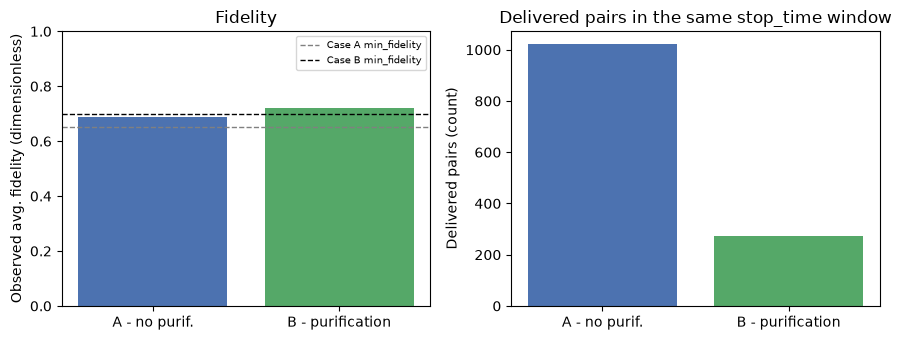

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

axes[0].bar(["A - no purif.", "B - purification"],
            [pairs_a_df["fidelity"].mean(), pairs_b_df["fidelity"].mean()],
            color=["#4C72B0", "#55A868"])
axes[0].axhline(intent_a.requirements.min_fidelity, color="gray", linestyle="--", linewidth=1, label="Case A min_fidelity")
axes[0].axhline(intent_b.requirements.min_fidelity, color="black", linestyle="--", linewidth=1, label="Case B min_fidelity")
axes[0].set_ylabel("Observed avg. fidelity (dimensionless)")
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=7)
axes[0].set_title("Fidelity")

axes[1].bar(["A - no purif.", "B - purification"],
            [len(evidence_a.delivered_pairs), len(evidence_b.delivered_pairs)],
            color=["#4C72B0", "#55A868"])
axes[1].set_ylabel("Delivered pairs (count)")
axes[1].set_title("Delivered pairs in the same stop_time window")

fig.tight_layout()
plt.show()


In [6]:
assert not plan_a.requires_purification, "Case A must NOT require purification (min_fidelity below swap-only estimate)"
assert plan_b.requires_purification, "Case B must require purification (min_fidelity above swap-only estimate)"
assert len(evidence_b.delivered_pairs) > 0, (
    "Case B delivered zero pairs: this is exactly the bug this notebook demonstrates the fix for - "
    "a stock RequestApp would silently ignore PURIFIED-state memories and never report these deliveries"
)
assert pairs_b_df["fidelity"].mean() >= intent_b.requirements.min_fidelity
print("Purified pairs were correctly counted and meet the higher fidelity requirement.")


Purified pairs were correctly counted and meet the higher fidelity requirement.


## Interpretação
Em Case A, o requisito (0.65) já é satisfeito pelo swap isolado
(~0.6864), então `PurifyUntilTarget` não aciona purificação: os pares são
entregues mais rápido, com fidelidade constante igual à estimativa de
swap. Em Case B, o requisito (0.70) excede o swap isolado mas fica abaixo
da estimativa de um round de purificação (`BBPSSWCircuit.improved_fidelity`,
~0.7203); o `ResourceManager` do SeQUeNCe instala automaticamente regras de
purificação, e os pares só são entregues depois de um round bem-sucedido -
por isso Case B tipicamente entrega **menos pares fim a fim, mais devagar,
porém com fidelidade observada mais alta** que Case A. Esses pares só
aparecem na tabela de resultados porque `IntentRequestApp.get_memory` trata
explicitamente o estado `"PURIFIED"` - sem essa correção, `delivered_pairs`
em Case B seria 0 mesmo com `ep_success` (diagnóstico, por nó) maior que
zero, uma divergência que seria silenciosa e não geraria nenhuma exceção.

## Limitações
- O número de rounds de purificação não é parametrizável nesta versão -
  SeQUeNCe só expõe `purification_mode='until_target'`
  (`src/ibqn/planning/purification.py`); a estimativa do planner assume um
  único round analítico, que pode divergir do número real de tentativas em
  tempo de execução.
- `ep_success` é um contador diagnóstico por nó (não por intent) - listado
  aqui apenas para contexto, nunca como prova de entrega
  (`docs/assurance_design.md`).

## Conclusão
Purificação demonstrada como decisão automática do planner acionada apenas
quando necessária, com contagem correta de pares purificados confirmada
por evidência real (`EventTypes.DELIVERY`), nunca por um valor calculado
fora da simulação.
